# From Conductance to Depolarization — A Simple Conductance-Based Membrane Model

**Learning goals**
1. Use $I_{\text{ion}} = g_{\text{ion}}(V - E_{\text{ion}})$ to compute ionic currents.
2. Combine conductances to find steady-state membrane potential $V_\infty$ and membrane time constant $\tau_m$.
3. Simulate how increasing $g_{\text{Na}}$ (opening Na⁺ channels) drives depolarization.
4. Extend to a minimal voltage-gated conductance model that can produce regenerative depolarization (spike-like).


## Background

**Nernst (monovalent ions)**

$$
E = \frac{RT}{zF}\,\ln\!\left(\frac{[\text{ion}]_{\text{out}}}{[\text{ion}]_{\text{in}}}\right)
$$

**Ohm’s law for membranes**

$$
I_{\text{ion}} = g_{\text{ion}}(V - E_{\text{ion}})
$$

**Membrane equation** (multiple conductances + applied current)

$$
C_m \frac{dV}{dt} = -\sum_i g_i(V - E_i) + I_{\text{app}}
$$

With constant conductances:

$$
V_\infty = \frac{\sum_i g_i E_i + I_{\text{app}}}{\sum_i g_i}, \qquad\tau_m = \frac{C_m}{\sum_i g_i}.
$$


In [1]:
import numpy as np

# Constants
R = 8.314     # J/(mol·K)
T = 310       # K (≈ 37°C)
F = 96485     # C/mol
z = 1         # monovalent
Cm = 1.0      # µF/cm^2

# Physiological concentrations (mM)
Na_out, Na_in = 145, 15
K_out,  K_in  = 5,   140

def nernst_mV(out, inside, z=1, T=310):
    return (R*T)/(z*F)*np.log(out/inside)*1000  # mV

E_Na = nernst_mV(Na_out, Na_in)   # ~ +60 mV
E_K  = nernst_mV(K_out,  K_in)    # ~ -90 mV
E_L  = -65.0                      # mV (phenomenological leak)

# Baseline conductances (mS/cm^2)
gL = 0.3
gK = 3.0

def steady_state_V_tau(gNa, gK=gK, gL=gL, E_Na=E_Na, E_K=E_K, E_L=E_L, Iapp=0.0, Cm=Cm):
    gtot = gNa + gK + gL
    V_inf = (gNa*E_Na + gK*E_K + gL*E_L + Iapp) / gtot
    tau_m = Cm / gtot  # ms
    return V_inf, tau_m

# Sweep g_Na
gNa_vals = np.linspace(0, 20, 11)  # 0..20 mS/cm^2
for g in gNa_vals:
    Vinf, tau = steady_state_V_tau(g)
    print(f"g_Na={g:4.1f} mS/cm^2 -> V_inf={Vinf:6.2f} mV, tau_m={tau:5.3f} ms")

print(f"E_Na≈{E_Na:.1f} mV, E_K≈{E_K:.1f} mV, E_L={E_L:.1f} mV")


g_Na= 0.0 mS/cm^2 -> V_inf=-86.83 mV, tau_m=0.303 ms
g_Na= 2.0 mS/cm^2 -> V_inf=-31.19 mV, tau_m=0.189 ms
g_Na= 4.0 mS/cm^2 -> V_inf= -6.04 mV, tau_m=0.137 ms
g_Na= 6.0 mS/cm^2 -> V_inf=  8.29 mV, tau_m=0.108 ms
g_Na= 8.0 mS/cm^2 -> V_inf= 17.55 mV, tau_m=0.088 ms
g_Na=10.0 mS/cm^2 -> V_inf= 24.02 mV, tau_m=0.075 ms
g_Na=12.0 mS/cm^2 -> V_inf= 28.80 mV, tau_m=0.065 ms
g_Na=14.0 mS/cm^2 -> V_inf= 32.48 mV, tau_m=0.058 ms
g_Na=16.0 mS/cm^2 -> V_inf= 35.39 mV, tau_m=0.052 ms
g_Na=18.0 mS/cm^2 -> V_inf= 37.76 mV, tau_m=0.047 ms
g_Na=20.0 mS/cm^2 -> V_inf= 39.72 mV, tau_m=0.043 ms
E_Na≈60.6 mV, E_K≈-89.0 mV, E_L=-65.0 mV


**Discuss/answer**
1. Why does $V_\infty$ move toward $E_{\text{Na}}$ as $g_{\text{Na}}$ increases?
2. Why does $\tau_m$ decrease when total conductance increases?
3. If $I_{\text{app}} > 0$, how do $V_\infty$ and $\tau_m$ change?


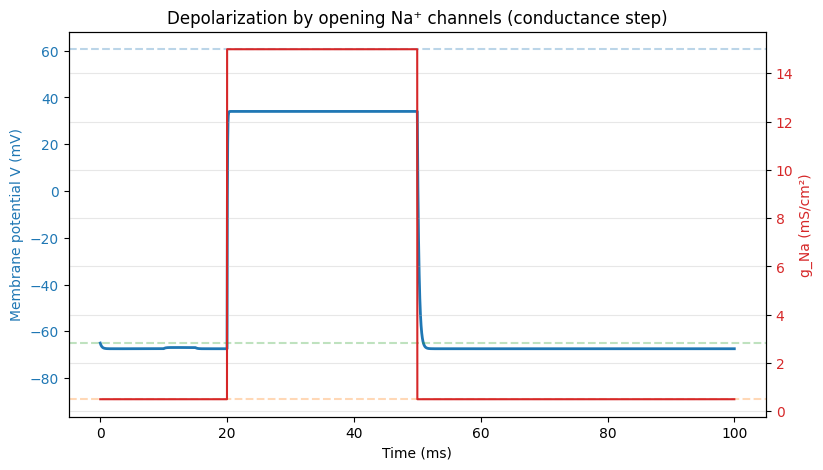

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Time
dt   = 0.01   # ms
tmax = 100.0  # ms
t    = np.arange(0, tmax+dt, dt)

# Conductance protocol: step open Na channels
gNa_base = 0.5
gNa_peak = 15.0
t_on, t_off = 20.0, 50.0  # ms

# Optional current injection
Iapp = np.zeros_like(t)
Iapp[(t>=10) & (t<15)] = 2.0  # µA/cm^2

# Prepare arrays
V = np.zeros_like(t); V[0] = -65.0
gNa_t = np.full_like(t, gNa_base)
gNa_t[(t>=t_on) & (t<t_off)] = gNa_peak

def dVdt(V, gNa, gK=gK, gL=gL, I=0.0):
    INa = gNa * (V - E_Na)
    IK  = gK  * (V - E_K)
    IL  = gL  * (V - E_L)
    Iion = INa + IK + IL
    return (-Iion + I)/Cm

# Integrate (Euler)
for i in range(len(t)-1):
    V[i+1] = V[i] + dt * dVdt(V[i], gNa_t[i], I=Iapp[i])

# Plot
plt.figure(figsize=(9,5))
ax1 = plt.gca()
ax1.plot(t, V, label='V (mV)', color='C0', lw=2)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Membrane potential V (mV)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.axhline(E_Na, ls='--', color='C0', alpha=0.3)
ax1.axhline(E_K,  ls='--', color='C1', alpha=0.3)
ax1.axhline(E_L,  ls='--', color='C2', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t, gNa_t, label='g_Na(t)', color='C3')
ax2.set_ylabel('g_Na (mS/cm²)', color='C3')
ax2.tick_params(axis='y', labelcolor='C3')

plt.title('Depolarization by opening Na⁺ channels (conductance step)')
plt.grid(True, alpha=0.3)
plt.show()


- Reduce $g_K$. What happens to $V(t)$?
- Change $(t_{\text{on}}, t_{\text{off}})$. Does the membrane track $V_\infty$ quickly or slowly? Relate to $\tau_m$.
- Increase $g_{\text{Na,peak}}$. How close does $V$ approach $E_{\text{Na}}$? Why is there no overshoot in this passive model?


## Minimal voltage-gated Na/K model

We introduce voltage- and time-dependent conductances for regenerative depolarization:

$$
\begin{aligned}
C_m \dot V &= -g_L(V-E_L) - g_{\text{Na}}(V-E_{\text{Na}}) - g_{\text{K}}(V-E_{\text{K}}) + I_{\text{app}} \\ 
g_{\text{Na}}(V,t) &= \bar g_{\text{Na}}\, m_\infty(V)^3\, h, \quad g_{\text{K}}(V,t)  = \bar g_{\text{K}}\, n^4 \\ 
\dot h &= \frac{h_\infty(V) - h}{\tau_h}, \qquad \dot n = \frac{n_\infty(V) - n}{\tau_n}
\end{aligned}
$$

We use sigmoids for steady-state gates: $x_\infty(V)=1/(1+e^{-(V-V_{1/2})/k})$.


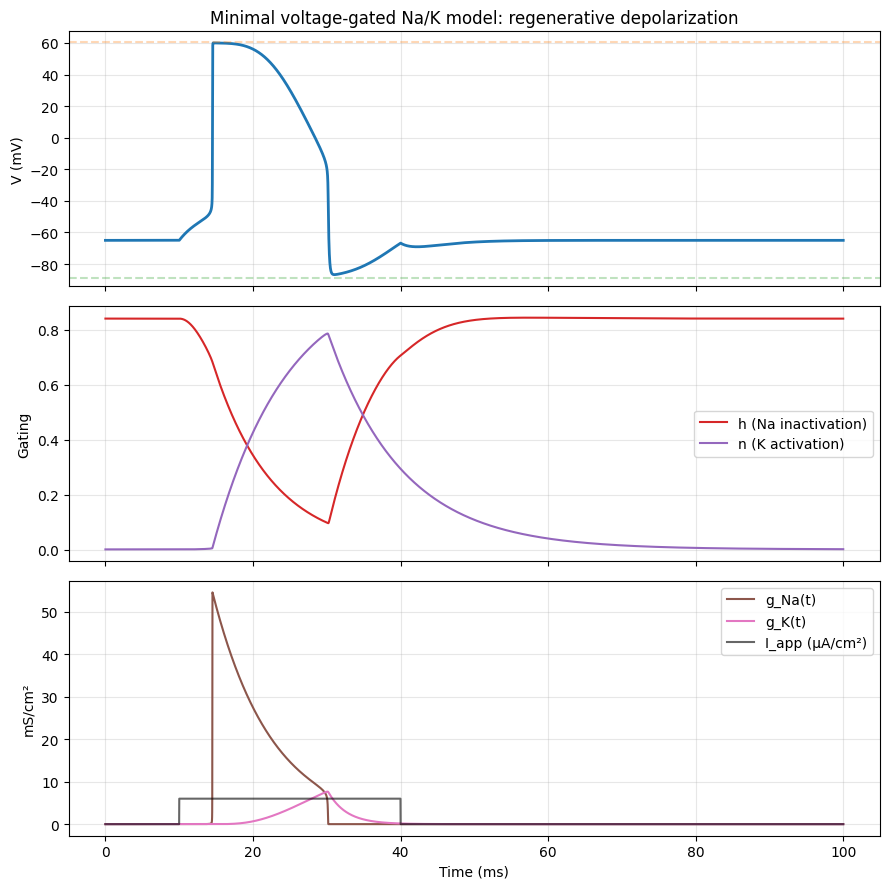

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Cm   = 1.0   # µF/cm^2
gL   = 0.3   # mS/cm^2
EL   = -65.0 # mV
# E_Na and E_K assumed from previous cells

gNa_bar = 80.0  # mS/cm^2
gK_bar  = 20.0  # mS/cm^2

def sigmoid(x):
    return 1/(1+np.exp(-x))

Vhalf_m, k_m = -35.0, 6.0
Vhalf_h, k_h = -55.0, -6.0  # negative slope → decreasing with V
Vhalf_n, k_n = -30.0, 5.0

def m_inf(V): return sigmoid((V - Vhalf_m)/k_m)
def h_inf(V): return sigmoid((V - Vhalf_h)/k_h)
def n_inf(V): return sigmoid((V - Vhalf_n)/k_n)

tau_h = 8.0   # ms
tau_n = 10.0  # ms

# Stimulation
dt, tmax = 0.01, 100.0
t = np.arange(0, tmax+dt, dt)
Iapp = np.zeros_like(t)
Iapp[(t>=10) & (t<40)] = 6.0  # µA/cm^2

# Initialize
V = np.zeros_like(t); V[0] = -65.0
h = np.zeros_like(t); h[0] = h_inf(V[0])
n = np.zeros_like(t); n[0] = n_inf(V[0])

def currents(V, h, n):
    gNa = gNa_bar * (m_inf(V)**3) * h
    gK  = gK_bar  * (n**4)
    INa = gNa*(V - E_Na)
    IK  = gK*(V - E_K)
    IL  = gL *(V - EL)
    return INa, IK, IL, gNa, gK

# Integrate
for i in range(len(t)-1):
    INa, IK, IL, gNa_i, gK_i = currents(V[i], h[i], n[i])
    dV = (-INa - IK - IL + Iapp[i]) / Cm
    dh = (h_inf(V[i]) - h[i]) / tau_h
    dn = (n_inf(V[i]) - n[i]) / tau_n
    V[i+1] = V[i] + dt*dV
    h[i+1] = h[i] + dt*dh
    n[i+1] = n[i] + dt*dn

# Plot
fig, axs = plt.subplots(3, 1, figsize=(9,9), sharex=True)
axs[0].plot(t, V, color='C0', lw=2)
axs[0].axhline(E_Na, ls='--', color='C1', alpha=0.3)
axs[0].axhline(E_K,  ls='--', color='C2', alpha=0.3)
axs[0].set_ylabel('V (mV)')
axs[0].set_title('Minimal voltage-gated Na/K model: regenerative depolarization')
axs[0].grid(True, alpha=0.3)

axs[1].plot(t, h, label='h (Na inactivation)', color='C3')
axs[1].plot(t, n, label='n (K activation)', color='C4')
axs[1].legend(); axs[1].set_ylabel('Gating'); axs[1].grid(True, alpha=0.3)

gNa_trace = gNa_bar*(m_inf(V)**3)*h
gK_trace  = gK_bar*(n**4)
axs[2].plot(t, gNa_trace, label='g_Na(t)', color='C5')
axs[2].plot(t, gK_trace,  label='g_K(t)',  color='C6')
axs[2].plot(t, Iapp,      label='I_app (µA/cm²)', color='k', alpha=0.6)
axs[2].legend(); axs[2].set_ylabel('mS/cm²'); axs[2].set_xlabel('Time (ms)')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**What to look for**
- With sufficient $I_{\text{app}}$ or $\bar g_{\text{Na}}$, you’ll see a regenerative upswing (fast depolarization), followed by repolarization as $h$ inactivates and $n$ activates.

**Questions**
1. Which term provides positive feedback for rapid depolarization?
2. Which mechanisms terminate depolarization and restore $V$?
3. Try changing $\bar g_{\text{Na}}$, $\bar g_{\text{K}}$, or the step amplitude. Identify a threshold.


In [4]:
# Optional: slope conductance around rest
def total_current(V, h, n):
    INa, IK, IL, _, _ = currents(V, h, n)
    return INa + IK + IL

def slope_conductance(V0, h0, n0, dV=1e-3):
    I1 = total_current(V0 + dV, h0, n0)
    I0 = total_current(V0 - dV, h0, n0)
    return (I1 - I0) / (2*dV)  # mS/cm^2

V0, h0, n0 = -65.0, h_inf(-65.0), n_inf(-65.0)
print('Slope conductance at rest (mS/cm^2):', slope_conductance(V0, h0, n0))


Slope conductance at rest (mS/cm^2): 0.29876172187943345


## Tips for equations in Jupyter

- Inline math: `$\tau_m = C_m/\sum g_i$` → τₘ = Cₘ/∑gᵢ
- Display math: 

  $$
  V_\infty = \frac{\sum_i g_i E_i + I_{\text{app}}}{\sum_i g_i}
  $$

- Matplotlib labels accept mathtext: `plt.ylabel(r'$V$ (mV)')`.
- Ensure you’re using a Markdown cell (not Code) for equations.


## Extension ideas

- Replace the sigmoids with full Hodgkin–Huxley $\alpha/\beta$ rate functions (temperature-corrected).
- Add Goldman–Hodgkin–Katz current for non-linear driving force at large voltages.
- Model synaptic conductances (excitatory $E_{\text{syn}}\approx 0$ mV; inhibitory $E_{\text{syn}}\approx -70$ mV) with exponential rise/decay.
